# Naïve Bayesian Classification on Iris Dataset

In [ ]:
!pip install seaborn

Tên các thuộc tính: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Tên các lớp: ['setosa' 'versicolor' 'virginica']
Kích thước dữ liệu: (150, 4)
Số mẫu huấn luyện: 105
Số mẫu kiểm thử: 45

--- Kết quả đánh giá ---
Độ chính xác: 0.9111111111111111

Báo cáo phân loại:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



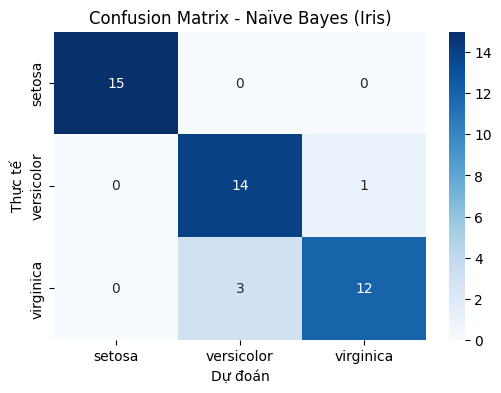

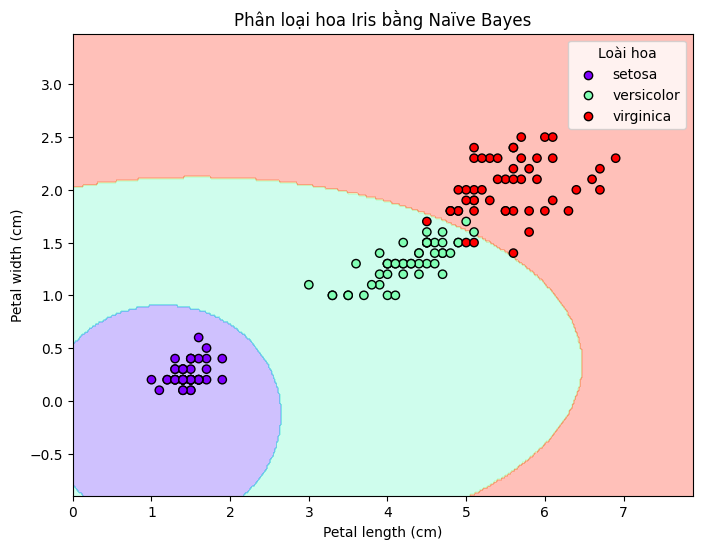

In [4]:
# --- Bước 1: Import thư viện cần thiết ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# --- Bước 2: Tải dữ liệu Iris ---
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Tên các thuộc tính:", feature_names)
print("Tên các lớp:", target_names)
print("Kích thước dữ liệu:", X.shape)

# --- Bước 3: Chia dữ liệu thành tập huấn luyện và kiểm thử ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Số mẫu huấn luyện:", len(X_train))
print("Số mẫu kiểm thử:", len(X_test))

# --- Bước 4: Khởi tạo và huấn luyện mô hình Naïve Bayes ---
model = GaussianNB()
model.fit(X_train, y_train)

# --- Bước 5: Dự đoán và đánh giá ---
y_pred = model.predict(X_test)

print("\n--- Kết quả đánh giá ---")
print("Độ chính xác:", accuracy_score(y_test, y_pred))
print("\nBáo cáo phân loại:")
print(classification_report(y_test, y_pred, target_names=target_names))

# --- Bước 6: Ma trận nhầm lẫn ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - Naïve Bayes (Iris)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()

# --- Bước 7: Trực quan hoá dữ liệu và ranh giới phân loại ---
# Chỉ dùng 2 thuộc tính để dễ minh họa (petal length và petal width)
X_vis = X[:, [2, 3]]
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y, test_size=0.3, random_state=42, stratify=y
)

model_vis = GaussianNB()
model_vis.fit(X_train_vis, y_train_vis)

# Vẽ ranh giới phân loại
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.rainbow)
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k', cmap=plt.cm.rainbow)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Phân loại hoa Iris bằng Naïve Bayes")

# --- Tạo legend ---
colors = plt.cm.rainbow(np.linspace(0, 1, len(target_names)))
for i, color in enumerate(colors):
    plt.scatter([], [], c=[color], label=target_names[i], edgecolor='k')
plt.legend(title="Loài hoa")

plt.show()
